#  Cat vs. Dog Image Classification with Augmentation

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D

from keras.losses import binary_crossentropy
from keras.optimizers import Adam

In [4]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
import cv2

In [6]:
import kagglehub
import os
import random

# Image Load

In [7]:
# Download latest version
path = kagglehub.dataset_download("anthonytherrien/dog-vs-cat")

print("Path to dataset files:", path)

# find images folder
print("Top-level folders:", os.listdir(path))

Using Colab cache for faster access to the 'dog-vs-cat' dataset.
Path to dataset files: /kaggle/input/dog-vs-cat
Top-level folders: ['animals']


In [10]:
my_dir = '/kaggle/input/dog-vs-cat/animals'
categories = ['cat', 'dog']
print(my_dir)
print(categories)

/kaggle/input/dog-vs-cat/animals
['cat', 'dog']


In [11]:
data = []

for category in categories:
    label = 0 if category == "cat" else 1
    path = os.path.join(my_dir, category)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (227, 227))

        data.append((img, label))

## Data Shuffle

In [12]:
random.shuffle(data)

In [13]:
type(data[0][0])

numpy.ndarray

# Image, Label Separate

In [14]:
x = []
y = []

for features, labels in data:
    x.append(features)
    y.append(labels)
print(len(x))
print(len(y))


1000
1000


In [15]:
type(x)

list

## Convert to Numpy Array

In [16]:
X = np.array(x)
y = np.array(y)

X.shape, y.shape

((1000, 227, 227, 3), (1000,))

## Visualize 12 sample images

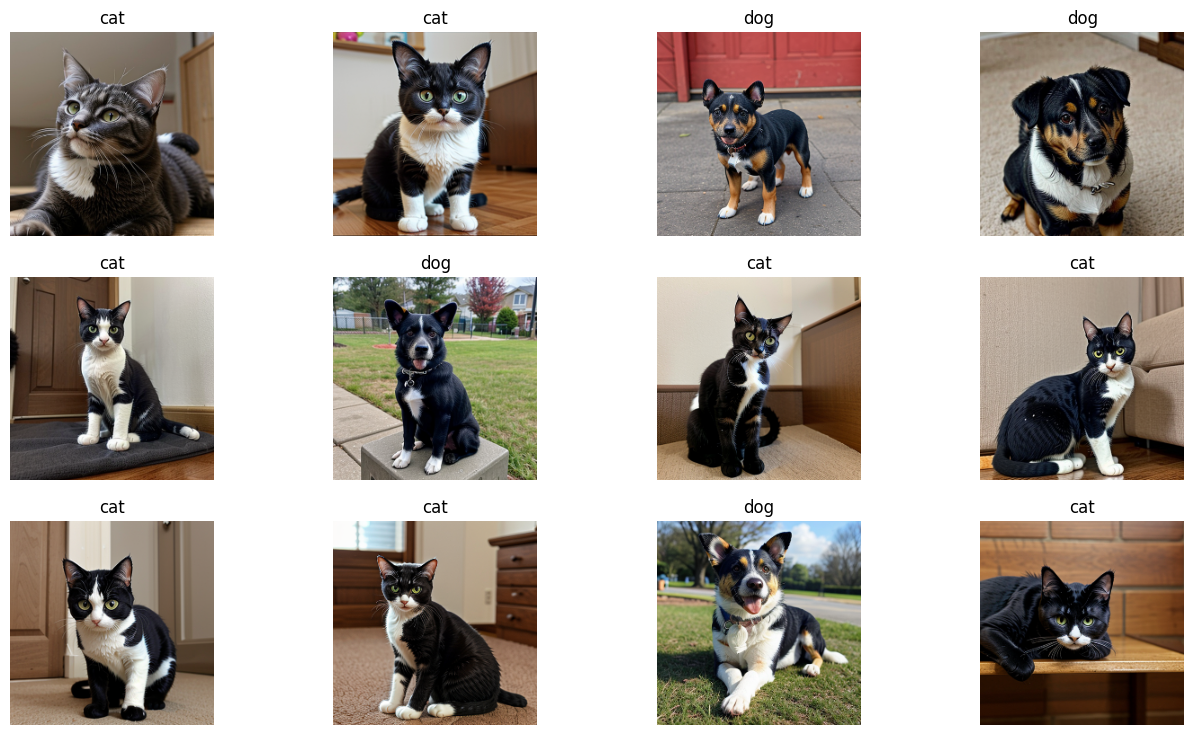

In [17]:
plt.figure(figsize=(16, 9))

for i in range(12):
    img, label = data[i]      # unpack
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert for matplotlib

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(categories[label])
    plt.axis("off")

plt.show()

# Normalize Image

In [18]:
X = X / 255.0
X.shape

(1000, 227, 227, 3)

# Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train.shape, X_test.shape

((800, 227, 227, 3), (200, 227, 227, 3))

# Custom Model `AlexNET`

In [21]:
def alexnet() -> Sequential:
  model = Sequential()

  # Input Layer
  model.add(Input(shape=(227, 227, 3)))

  # Convolution Layer 1
  model.add(Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), activation='relu', padding='valid'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

  # Convolution Layer 2
  model.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(2, 2), activation='relu', padding='valid'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

  # Convolution Layer 3
  model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same')) # Changed to 'same'
  model.add(BatchNormalization())

  # Convolution Layer 4
  model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same')) # Changed to 'same'
  model.add(BatchNormalization())

  # Convolution Layer 5
  model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same')) # Changed to 'same'
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

  # Flatten Layer
  model.add(Flatten())

  # Full connected layer
  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(
      optimizer=Adam(learning_rate=0.001),
      loss=tf.keras.losses.binary_crossentropy,
      metrics=['accuracy']
  )

  return model

In [22]:
model1 = alexnet()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 5, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,736,513 (94.36 MB)

 Trainable params: 24,733,761 (94.35 MB)

 Non-trainable params: 2,752 (10.75 KB)

## Model Training

In [23]:
history1 = model1.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=1,
    batch_size=32
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.5994 - loss: 7.7751 - val_accuracy: 0.5200 - val_loss: 7.6032
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8562 - loss: 0.3696 - val_accuracy: 0.5200 - val_loss: 8.5421
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8802 - loss: 0.3319 - val_accuracy: 0.5100 - val_loss: 2.7263
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9445 - loss: 0.1397 - val_accuracy: 0.5600 - val_loss: 2.4766
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9604 - loss: 0.1266 - val_accuracy: 0.7200 - val_loss: 1.0013
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9645 - loss: 0.0957 - val_accuracy: 0.7450 - val_loss: 1.0847
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9692 - loss: 0.0859 - val_accuracy: 0.5600 - val_loss: 2.7044
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9661 - loss: 0.0903 - val_accuracy: 0.8050 -

## Accuracy Plot

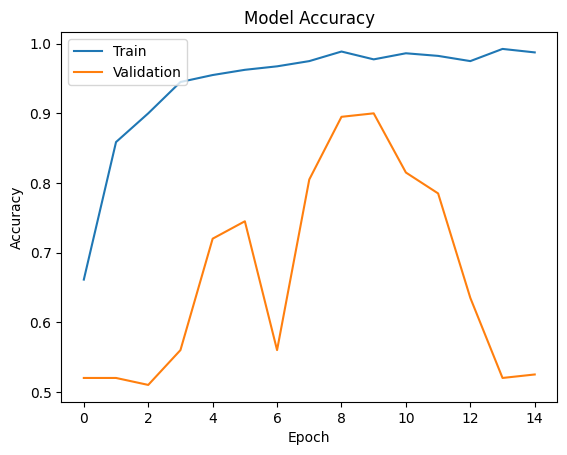

In [24]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Loss Plot

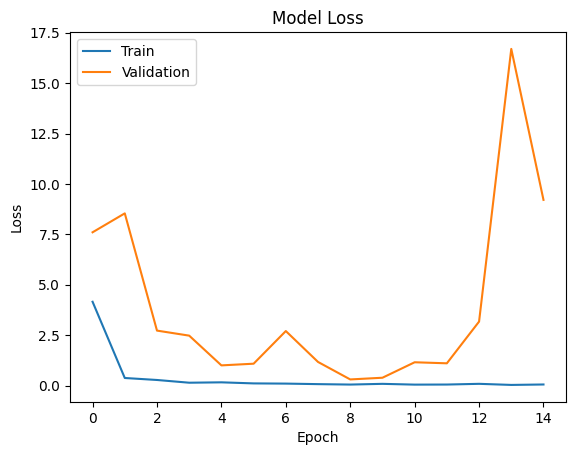

In [25]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# VGGNET-16

In [26]:
def vggnet():
  model = Sequential()

  # Input Layer
  model.add(Input(shape=(227, 227, 3)))

  # 1st Convolutional Layer
  model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # 2nd Convolutional Layer
  model.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # 3rd Convolutional Layer
  model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # 4th Convolutional Layer
  model.add(Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # 5th Convolutional Layer
  model.add(Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

  # Flatten Layer
  model.add(Flatten())

  # Full connected layer
  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(4096, activation='relu'))
  model.add(Dropout(0.5))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(
      optimizer=Adam(learning_rate=0.001),
      loss=tf.keras.losses.binary_crossentropy,
      metrics=['accuracy']
  )

  return model

## Model Build

In [27]:
model2 = vggnet()
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 227, 227, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 227, 227, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 113, 113, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 113, 113, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 134,264,641 (512.18 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [28]:
history2 = model2.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=1,
    batch_size=32
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4794 - loss: 0.9617 - val_accuracy: 0.4800 - val_loss: 0.6938
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 538ms/step - accuracy: 0.5046 - loss: 0.6933 - val_accuracy: 0.4800 - val_loss: 0.6932
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.4647 - loss: 0.6933 - val_accuracy: 0.4800 - val_loss: 0.6941
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 532ms/step - accuracy: 0.4774 - loss: 0.6942 - val_accuracy: 0.4800 - val_loss: 0.6948
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 532ms/step - accuracy: 0.4840 - loss: 0.6948 - val_accuracy: 0.4800 - val_loss: 0.6933
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 532ms/step - accuracy: 0.4982 - loss: 0.6930 - val_accuracy: 0.4800 - val_loss: 0.6956
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 532ms/step - accuracy: 0.4773 - loss: 0.6961 - val_accuracy: 0.5200 - val_loss: 0.6930
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.4776 - loss: 0.6933 - val_accurac

## Accuracy Plot

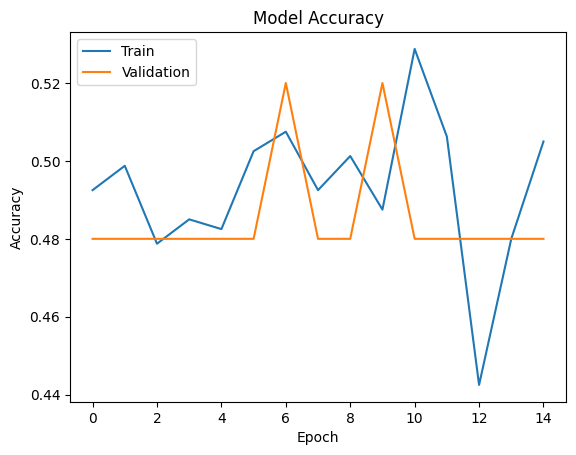

In [29]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

## Loss Plot

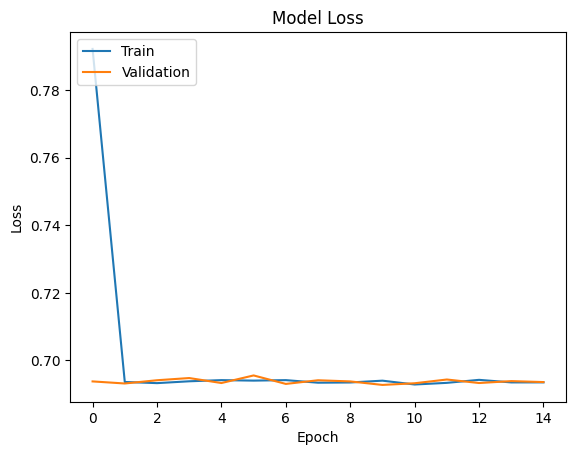

In [30]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')